# Лабораторная работа №2: Предобработка данных

## 1. Текстовое описание набора данных
В данной работе исследуется набор данных **Titanic**, содержащий информацию о пассажирах затонувшего лайнера.
- **Цель:** Подготовить данные для дальнейшего обучения моделей.
- **Особенности:** Датасет содержит пропуски в числовых и категориальных данных, а также признаки разных типов и шкал.

---

## 2. Загрузка данных и анализ пропусков


Информация о пропусках в данных:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


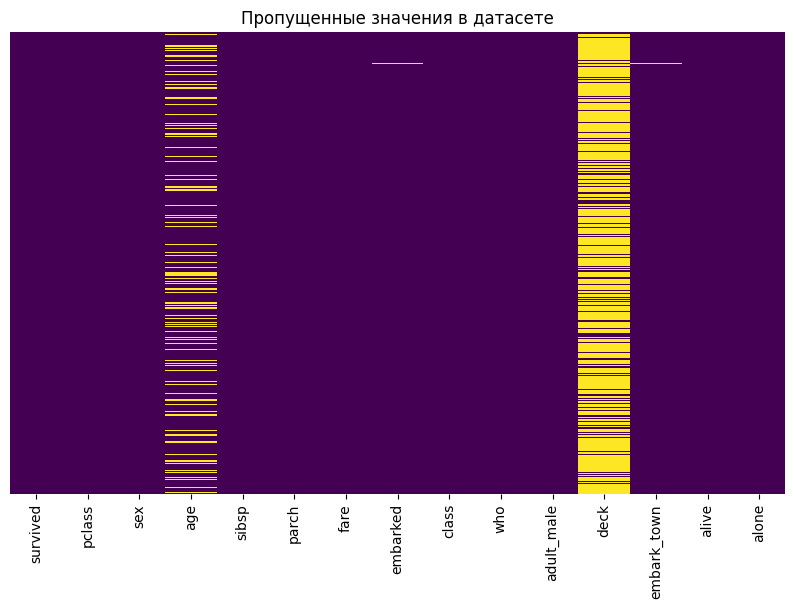

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

# Загрузка датасета Titanic из встроенной библиотеки seaborn
df = sns.load_dataset('titanic')

# Вывод информации о пропусках
print("Информация о пропусках в данных:")
print(df.isnull().sum())

# Визуализация пропусков
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Пропущенные значения в датасете')
plt.show()

## 3. Обработка пропусков в данных

Мы применим два подхода:
1. **Числовые данные (Age):** Заполним медианой.
2. **Категориальные данные (Embarked):** Заполним самым частым значением (модой).
3. **Удаление:** Столбец `deck` имеет слишком много пропусков (>70%), его целесообразно удалить.

In [3]:
# 1. Заполнение пропусков для Age (числовой признак)
imputer_num = SimpleImputer(strategy='median')
# Используем .ravel(), чтобы превратить 2D массив в 1D
df['age'] = imputer_num.fit_transform(df[['age']]).ravel()

# 2. Заполнение пропусков для Embarked (категориальный признак)
imputer_cat = SimpleImputer(strategy='most_frequent')

# Способ А: через .ravel() (самый надежный)
df['embarked'] = imputer_cat.fit_transform(df[['embarked']]).ravel()

# Способ Б: передать список колонок в левой части, чтобы Pandas ожидал 2D массив
df[['embark_town']] = imputer_cat.fit_transform(df[['embark_town']])

# 3. Удаление лишних столбцов
# (Проверьте, есть ли в вашем датасете эти колонки, в seaborn titanic они обычно есть)
columns_to_drop = ['deck', 'alive', 'who', 'adult_male']
df.drop(columns=[c for c in columns_to_drop if c in df.columns], inplace=True)

# Проверка результата
print(f"Оставшиеся пропуски:\n{df.isnull().sum()}")

Оставшиеся пропуски:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
embark_town    0
alone          0
dtype: int64



## 4. Кодирование категориальных признаков

Для обучения моделей машинного обучения текстовые данные должны быть преобразованы в числа.

### 4.1 Label Encoding
Используется для бинарных признаков (где всего 2 значения).

In [4]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
# 1 - male, 0 - female
print(f"Первые значения 'sex' после Label Encoding: {df['sex'].head().values}")

Первые значения 'sex' после Label Encoding: [1 0 0 0 1]


### 4.2 One-Hot Encoding
Используется для признаков с несколькими категориями, чтобы не вводить ложный "порядок" между ними (например, Embarked: C, Q, S).

In [5]:
# Применим get_dummies (удобный аналог OneHotEncoder в pandas)
df = pd.get_dummies(df, columns=['embarked', 'embark_town', 'class'], drop_first=False)

# Выведем результат (новые колонки)
print("Новые колонки после One-Hot Encoding:")
print([col for col in df.columns if 'class' in col or 'embarked' in col])
df.head()

Новые колонки после One-Hot Encoding:
['pclass', 'embarked_C', 'embarked_Q', 'embarked_S', 'class_First', 'class_Second', 'class_Third']


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,class_First,class_Second,class_Third
0,0,3,1,22.0,1,0,7.2500,False,False,False,True,False,False,True,False,False,True
1,1,1,0,38.0,1,0,71.2833,False,True,False,False,True,False,False,True,False,False
2,1,3,0,26.0,0,0,7.9250,True,False,False,True,False,False,True,False,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,False,True,False,False,True,True,False,False
4,0,3,1,35.0,0,0,8.0500,True,False,False,True,False,False,True,False,False,True


## 5. Масштабирование данных

Признаки `age` (возраст) и `fare` (цена билета) имеют разные диапазоны. Применим два популярных метода.

### 5.1 Min-Max Scaling (Нормализация)
Приводит данные к диапазону [0, 1].

In [7]:
sc_minmax = MinMaxScaler()
df['age_minmax'] = sc_minmax.fit_transform(df[['age']])

print(f"Диапазон Age после MinMaxScaler: [{df['age_minmax'].min()}, {df['age_minmax'].max()}]")

Диапазон Age после MinMaxScaler: [0.0, 1.0]



### 5.2 StandardScaler (Стандартизация)
Приводит данные к среднему 0 и стандартному отклонению 1. Полезно для алгоритмов, чувствительных к распределению.

In [8]:
sc_std = StandardScaler()
df['fare_std'] = sc_std.fit_transform(df[['fare']])

print(f"Среднее Fare после StandardScaler: {df['fare_std'].mean():.2f}")
print(f"Стандартное отклонение Fare: {df['fare_std'].std():.2f}")

Среднее Fare после StandardScaler: 0.00
Стандартное отклонение Fare: 1.00


## Итоговый результат


In [9]:

# Финальный вид данных
print("Размерность итогового датасета:", df.shape)
df.head()

Размерность итогового датасета: (891, 19)


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,class_First,class_Second,class_Third,age_minmax,fare_std
0,0,3,1,22.0,1,0,7.2500,False,False,False,True,False,False,True,False,False,True,0.271174,-0.502445
1,1,1,0,38.0,1,0,71.2833,False,True,False,False,True,False,False,True,False,False,0.472229,0.786845
2,1,3,0,26.0,0,0,7.9250,True,False,False,True,False,False,True,False,False,True,0.321438,-0.488854
3,1,1,0,35.0,1,0,53.1000,False,False,False,True,False,False,True,True,False,False,0.434531,0.420730
4,0,3,1,35.0,0,0,8.0500,True,False,False,True,False,False,True,False,False,True,0.434531,-0.486337


### Краткие выводы по работе:
1.  **Пропуски**: Были заполнены статистическими методами (медиана и мода), что позволило сохранить объем выборки.
2.  **Категории**: Были преобразованы в числовой вид. Для пола использовано бинарное кодирование, для городов и классов — One-Hot Encoding.
3.  **Масштабирование**: Признаки приведены к единому масштабу, что необходимо для корректной работы линейных моделей и метода ближайших соседей (k-NN).